# 05장 데이터 전처리 필사 정리

파이썬 머신러닝 완벽 가이드(개정2판) 5장 '데이터 전처리' 필사 과제

- 개념 설명은 내 언어로 정리함
- 코드는 책에 있는 그대로 누락 없이 옮겨 적음

## 01. 데이터 전처리란

머신러닝 알고리즘이 잘 작동할 수 있도록 데이터를 사전에 다듬는 과정임. 사이킷런의 알고리즘은 문자열 값을 입력으로 받지 않기 때문에, 데이터에 들어있는 모든 문자열 값은 인코딩돼서 숫자형으로 변환돼야 함.

- 카테고리형(범주형) 피처는 코드 값으로 표현하면 됨
- 텍스트형 피처는 피처 벡터화 등의 기법으로 벡터화하거나, 예측에 중요하지 않다면 삭제하는 게 나음
- 특히 주민번호나 단순 아이디처럼 단순 문자열이면서 데이터 건수만 차지하는 피처는 예측에 도움이 안 되므로 삭제하는 게 좋음

또한 결측값(Null/NaN)은 사이킷런 알고리즘에서 허용되지 않기 때문에 다른 값으로 대체해야 함. 결측치가 얼마 되지 않는다면 피처의 평균값 등으로 간단히 대체할 수 있지만, 결측치 비중이 대부분이라면 오히려 해당 피처를 드롭하는 게 나을 수도 있고, 결측치가 어느 정도 있다면 해당 피처가 중요도가 높은 피처이고 단순히 평균값을 대체하면 예측 왜곡이 심할 수 있는 경우 정교한 대체값을 선정해야 함.

## 02. 데이터 인코딩

### 레이블 인코딩 (Label Encoding)

카테고리 피처를 코드형 숫자 값으로 변환하는 것. 예를 들어 상품 데이터의 상품 구분이 TV, 냉장고, 전자레인지, 컴퓨터, 선풍기, 믹서 등으로 돼 있다면 이를 0, 1, 2, 3, 4, 5 값으로 변환함.

사이킷런의 `LabelEncoder` 클래스로 구현함. `LabelEncoder`를 객체로 생성한 후 `fit()`과 `transform()`을 호출해 레이블 인코딩을 수행함.

In [1]:
from sklearn.preprocessing import LabelEncoder

items=['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

# LabelEncoder를 객체로 생성한 후, fit( )과 transform( )으로 레이블 인코딩 수행.
encoder = LabelEncoder()
encoder.fit(items)
labels = encoder.transform(items)
print('인코딩 변환값:', labels)

인코딩 변환값: [0 1 4 5 3 3 2 2]


`classes_` 속성값으로 문자열 값이 어떤 숫자 값으로 인코딩됐는지 확인할 수 있음. `classes_`는 0번부터 순서대로 변환된 인코딩 값에 대한 원본값을 가지고 있음.

In [2]:
print('인코딩 클래스:', encoder.classes_)

인코딩 클래스: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


`inverse_transform()`을 이용하면 인코딩된 값을 다시 디코딩할 수 있음.

In [3]:
print('디코딩 원본값:', encoder.inverse_transform([4, 5, 2, 0, 1, 1, 3, 3]))

디코딩 원본값: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


레이블 인코딩은 간단하게 문자열 값을 숫자형 카테고리 값으로 변환하지만, 이렇게 변환된 숫자 값의 크고 작음에 대한 특성이 작용하기 때문에 몇몇 ML 알고리즘에는 이런 특성이 예측 성능을 떨어뜨릴 수 있음. 숫자 값의 경우 크기 차이가 있기 때문에 특정 ML 알고리즘(선형회귀 등)에서는 이를 가중치가 더 부여되거나 중요하게 인식할 가능성이 있음. 트리 계열의 ML 알고리즘은 이러한 숫자의 특성을 반영하지 않으므로 레이블 인코딩도 문제 없지만, 그 외의 알고리즘에는 레이블 인코딩을 적용하지 않아야 함.

### 원-핫 인코딩 (One-Hot Encoding)

레이블 인코딩의 이런 문제점을 해결하기 위한 방식임. 피처 값의 유형에 따라 새로운 피처를 추가해 고유 값에 해당하는 컬럼에만 1을 표시하고 나머지 컬럼에는 0을 표시하는 방식임.

`OneHotEncoder` 클래스로 변환 가능한데, 주의할 점이 두 가지 있음.
1. `OneHotEncoder`로 변환하기 전에 모든 문자열 값이 숫자형 값으로 변환돼야 하고, 입력값으로 2차원 데이터가 필요함
2. 변환 결과가 희소 행렬(Sparse Matrix)이므로 `toarray()`를 이용해 밀집 행렬로 변환해야 실제 값을 확인할 수 있음

In [4]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

items=['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']

# 2차원 ndarray로 변환합니다.
items = np.array(items).reshape(-1, 1)

# 원-핫 인코딩을 적용합니다.
oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

# OneHotEncoder로 변환한 결과는 희소행렬이므로 toarray()를 이용해 밀집 행렬로 변환.
print('원-핫 인코딩 데이터')
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)

원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


판다스에는 원-핫 인코딩을 더 쉽게 지원하는 API인 `get_dummies()`가 있음. 숫자형 값으로 변환 없이 바로 문자열 카테고리 값을 원-핫 인코딩할 수 있어 편리함.

In [5]:
import pandas as pd

df = pd.DataFrame({'item':['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']})
pd.get_dummies(df)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,False,False,True
4,False,False,False,True,False,False
5,False,False,False,True,False,False
6,False,False,True,False,False,False
7,False,False,True,False,False,False


## 03. 피처 스케일링과 정규화

서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업을 피처 스케일링(feature scaling)이라고 함. 대표적인 방법으로 표준화(Standardization)와 정규화(Normalization)가 있음.

- **표준화**: 데이터의 피처 각각을 평균이 0이고 분산이 1인 가우시안 정규 분포를 가진 값으로 변환하는 것
- **정규화**: 서로 다른 피처의 크기를 통일하기 위해 크기를 변환해주는 개념. 즉 개별 데이터의 크기를 모두 똑같은 단위로 변경하는 것(대체로 0~1 사이 값으로 변환)

사이킷런에서 제공하는 대표적인 피처 스케일링 클래스는 `StandardScaler`(표준화 지원)와 `MinMaxScaler`(정규화 지원)임.

### StandardScaler

개별 피처를 평균이 0이고 분산이 1인 값으로 변환해줌. 가우시안 정규 분포를 가정하고 구현된 알고리즘(서포트 벡터 머신, 선형회귀, 로지스틱회귀 등)에서는 사전에 데이터를 표준화하는 것이 예측 성능 향상에 중요한 요소가 될 수 있음.

In [6]:
from sklearn.datasets import load_iris
import pandas as pd
# 붓꽃 데이터 세트를 로딩하고 DataFrame으로 변환합니다.
iris = load_iris()
iris_data = iris.data
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)

print('feature 들의 평균 값')
print(iris_df.mean())
print('\nfeature 들의 분산 값')
print(iris_df.var())

feature 들의 평균 값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

feature 들의 분산 값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [7]:
from sklearn.preprocessing import StandardScaler

# StandardScaler객체 생성
scaler = StandardScaler()
# StandardScaler로 데이터 세트 변환. fit( )과 transform( ) 호출.
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# transform( ) 시 스케일 변환된 데이터 세트가 NumPy ndarray로 반환돼 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('feature 들의 평균 값')
print(iris_df_scaled.mean())
print('feature 들의 분산 값')
print(iris_df_scaled.var())

feature 들의 평균 값
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64
feature 들의 분산 값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


모든 컬럼 값의 평균이 0에 아주 가깝고, 분산은 1에 아주 가까운 값으로 변환됐음을 확인할 수 있음.

### MinMaxScaler

데이터값을 0과 1 사이의 범위 값으로 변환함(음수 값이 있으면 -1에서 1값으로 변환). 데이터의 분포가 가우시안 분포가 아닐 경우에 Min, Max 값을 이용한 스케일링을 적용해볼 수 있음.

In [8]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler객체 생성
scaler = MinMaxScaler()
# MinMaxScaler로 데이터 세트 변환. fit()과 transform() 호출.
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# transform() 시 스케일 변환된 데이터 세트가 NumPy ndarray로 반환돼 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('feature들의 최솟값')
print(iris_df_scaled.min())
print('\nfeature들의 최댓값')
print(iris_df_scaled.max())

feature들의 최솟값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

feature들의 최댓값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


모든 피처에서 최솟값은 0, 최댓값은 1로 변환됐음.

### 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점

`Scaler` 객체를 이용해 데이터의 스케일링 변환 시 `fit()`, `transform()`, `fit_transform()` 메서드를 이용함. `fit()`은 데이터 변환을 위한 기준 정보(최댓값/최솟값 등)를 설정하는 것이고, `transform()`은 이렇게 설정된 정보를 이용해 데이터를 변환하는 것임.

여기서 중요한 점은, **학습 데이터로 `fit()`이 적용된 스케일링 기준 정보를 그대로 테스트 데이터에도 적용**해야 한다는 것임. 테스트 데이터로 다시 `fit()`을 수행하면 학습 데이터와 테스트 데이터의 스케일링 기준 정보가 서로 달라지기 때문에 올바른 예측 결과를 만들어내지 못할 수 있음. 따라서 테스트 데이터에는 `fit()`을 호출하지 않고, 학습 데이터로 이미 `fit()`된 `Scaler` 객체를 이용해 `transform()`만 수행해야 함. 가능하다면 전체 데이터에 스케일링 변환을 적용한 뒤에 학습 데이터와 테스트 데이터로 분리하는 것이 더 바람직함.

아래 예제로 이 문제를 직접 확인해볼 수 있음.

In [9]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 학습 데이터는 0부터 10까지, 테스트 데이터는 0부터 5까지 값을 가지는 데이터 세트로 생성
# Scaler 클래스의 fit(), transform()은 2차원 이상 데이터만 가능하므로 reshape(-1, 1)로 차원 변경
train_array = np.arange(0, 11).reshape(-1, 1)
test_array =  np.arange(0, 6).reshape(-1, 1)

In [10]:
# MinMaxScaler 객체에 별도의 feature_range 파라미터 값을 지정하지 않으면 0~1 값으로 변환
scaler = MinMaxScaler()

# fit()하게 되면 train_array 데이터의 최솟값이 0, 최댓값이 10으로 설정.
scaler.fit(train_array)

# 1/10 scale로 train_array 데이터 변환함. 원본 10-> 1로 변환됨.
train_scaled = scaler.transform(train_array)

print('원본 train_array 데이터:', np.round(train_array.reshape(-1), 2))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1), 2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


이번엔 `test_array`에 `MinMaxScaler`를 그대로 `fit()`을 호출하고 `transform()`하면 어떻게 되는지 확인해봄.

In [11]:
# MinMaxScaler에 test_array를 fit()하게 되면 원본 데이터의 최솟값이 0, 최댓값이 5로 설정됨
scaler.fit(test_array)

# 1/5 scale로 test_array 데이터 변환함. 원본 5->1로 변환.
test_scaled = scaler.transform(test_array)

# test_array의 scale 변환 출력.
print('원본 test_array 데이터:', np.round(test_array.reshape(-1), 2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1), 2))

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.2 0.4 0.6 0.8 1. ]


출력 결과를 보면 학습 데이터와 테스트 데이터의 스케일이 서로 다르게 적용된 것을 확인할 수 있음(원본 데이터의 1과 5가 스케일링 후 서로 다른 값으로 변환됨). 머신러닝 모델은 학습 데이터를 기반으로 학습되기 때문에 반드시 테스트 데이터도 학습 데이터와 동일한 스케일링 기준이 적용돼야 함. 따라서 테스트 데이터에 다시 `fit()`을 적용해서는 안 되고, 학습 데이터로 이미 `fit()`된 `Scaler` 객체를 이용해 `transform()`으로만 변환해야 함.

In [12]:
scaler = MinMaxScaler()
scaler.fit(train_array)
train_scaled = scaler.transform(train_array)
print('원본 train_array 데이터:', np.round(train_array.reshape(-1), 2))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1), 2))

# test_array에 Scale 변환을 할 때는 반드시 fit()을 호출하지 않고 transform()만으로 변환해야 함.
test_scaled = scaler.transform(test_array)
print('\n원본 test_array 데이터:', np.round(test_array.reshape(-1), 2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1), 2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5]


이번에는 학습 데이터의 스케일링 기준을 그대로 테스트 데이터에 적용했기 때문에 두 데이터의 스케일이 같은 기준으로 일관되게 변환된 것을 확인할 수 있음. 이 규칙은 뒤에서 배울 PCA와 같은 차원 축소 변환이나 텍스트의 피처 벡터화 변환 시에도 동일하게 적용됨.

## 06. 사이킷런으로 수행하는 타이타닉 생존자 예측

지금까지 배운 결측치 처리, 인코딩, 데이터 탐색, 피처 가공 등의 내용을 실제 데이터인 캐글의 타이타닉 탑승자 데이터에 적용해서 생존자를 예측해보는 실습임. 승객의 나이, 성별, 좌석 등급 등 다양한 피처를 이용해 탑승자의 생존 여부(0 또는 1)를 예측하는 이진 분류 문제임.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [14]:
titanic_df = pd.read_csv('./titanic_train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


`info()` 메서드를 통해 컬럼별로 데이터 타입과 Null 건수를 확인함.

In [15]:
print('\n ### 학습 데이터 정보 ### \n')
print(titanic_df.info())


 ### 학습 데이터 정보 ### 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


DataFrame의 `fillna()` 함수를 사용해 Null 값을 평균 또는 고정 값으로 대체함. Age는 평균 나이로, Cabin과 Embarked는 'N'이라는 임의의 값으로 대체함.

In [16]:
titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
titanic_df['Cabin'].fillna('N', inplace=True)
titanic_df['Embarked'].fillna('N', inplace=True)
print('데이터 세트 Null 값 개수 ', titanic_df.isnull().sum().sum())

데이터 세트 Null 값 개수  0


/tmp/ipykernel_622/855427041.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
/tmp/ipykernel_622/855427041.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

남아 있는 문자열 피처인 Sex, Cabin, Embarked의 값 분류를 살펴봄.

In [17]:
print(' Sex 값 분포 :\n', titanic_df['Sex'].value_counts())
print('\n Cabin 값 분포 :\n', titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포 :\n', titanic_df['Embarked'].value_counts())

 Sex 값 분포 :
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 :
 Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포 :
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


Cabin(선실) 값은 선실 번호까지 상세하게 기재돼 있는데, 여기서는 선실 등급을 나타내는 첫 번째 알파벳만 추출해서 사용함.

In [18]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


어떤 피처가 생존 확률에 영향을 미치는지 확인하기 위해 성별에 따른 생존자 수를 비교함.

In [19]:
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

이를 seaborn의 `barplot()`을 이용해 시각화함.

<Axes: xlabel='Sex', ylabel='Survived'>

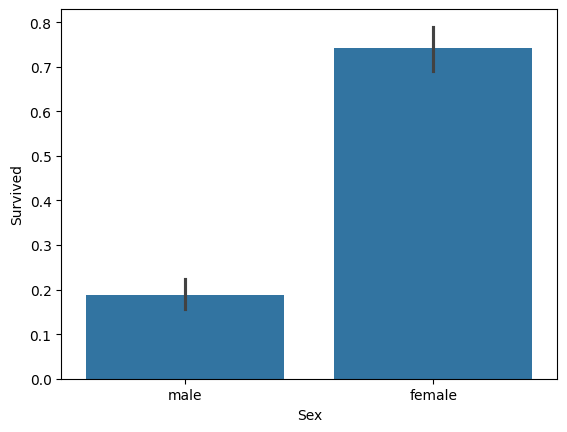

In [20]:
sns.barplot(x='Sex', y = 'Survived', data=titanic_df)

이번엔 성별에 더해 객실 등급(Pclass)까지 함께 고려해 생존율을 비교함. `hue` 파라미터에 Sex를 지정하면 X축을 Pclass, 색상 구분을 Sex로 세분화한 바 플롯을 그릴 수 있음.

<Axes: xlabel='Pclass', ylabel='Survived'>

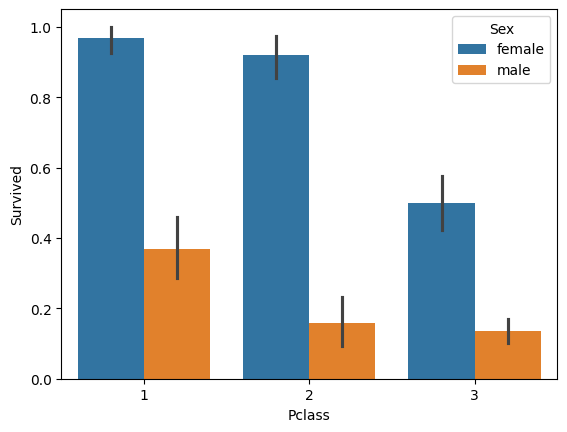

In [21]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)

여성, 그중에서도 1등실 여성 승객의 생존 확률이 상대적으로 높았음을 확인할 수 있음. 이번엔 나이에 따른 생존 확률도 확인해봄. Age는 연속된 숫자값이므로, 나이대별 카테고리 값으로 나눠서 분석함. `get_category()` 함수를 만들어 나이에 따라 Unknown, Baby, Child, Teenager, Student, Young Adult, Adult, Elderly 값을 반환하도록 하고, 이를 `apply(lambda)` 식으로 DataFrame에 적용함.

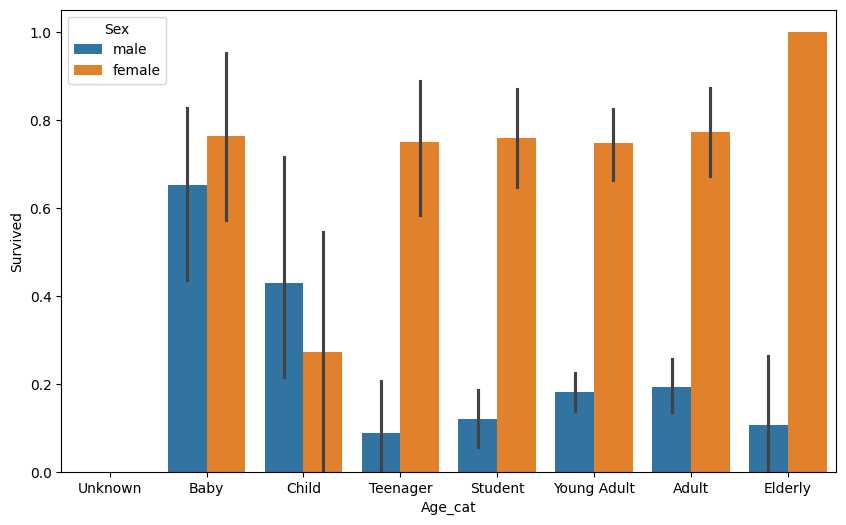

In [22]:
# 입력 age에 따라 구분 값을 반환하는 함수 설정. DataFrame의 apply lambda 식에 사용.
def get_category(age):
    cat = ''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else : cat = 'Elderly'

    return cat

# 막대그래프의 크기 figure를 더 크게 설정
plt.figure(figsize=(10, 6))

# X축의 값을 순차적으로 표시하기 위한 설정
group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']

# lambda 식에 위에서 생성한 get_category( ) 함수를 반환값으로 지정.
# get_category(X)는 입력값으로 'Age' 컬럼 값을 받아서 해당하는 cat 반환
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x : get_category(x))
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)

여자 Baby의 경우 비교적 생존 확률이 높았고, 여자 Child의 경우는 다른 연령대에 비해 생존 확률이 낮았음. 여자 Elderly의 경우는 매우 생존 확률이 높았음. 이 분석을 통해 Sex, Age, Pclass 등이 생존 여부를 좌우하는 중요한 피처임을 어느 정도 확인할 수 있었음.

이제 남아 있는 문자열 카테고리 피처를 숫자형 카테고리 피처로 변환함. 인코딩은 `LabelEncoder`를 이용한 레이블 인코딩을 적용함. 여러 컬럼을 한 번에 변환할 수 있도록 `encode_features()` 함수를 새로 만듦.

In [23]:
from sklearn.preprocessing import LabelEncoder

def encode_features(dataDF):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder( )
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])

    return dataDF

titanic_df = encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


Sex, Cabin, Embarked 속성이 숫자형으로 바뀐 것을 확인할 수 있음.

지금까지 진행한 피처 가공 내역(Null 처리, 불필요한 피처 제거, 인코딩)을 함수로 정리해서 재사용 가능하게 만듦. 데이터의 전처리를 전체적으로 호출하는 함수는 `transform_features()`이며, Null 처리, 불필요한 피처 제거, 인코딩을 수행하는 내부 함수들로 구성함. 불필요한 피처 제거는 `drop_features(df)`로 수행하며, 머신러닝 알고리즘에 불필요한 단순 식별자 수준의 피처인 PassengerId, Name, Ticket 피처를 제거함.

In [24]:
# Null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행.
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

이렇게 만든 `transform_features()` 함수를 이용해 원본 데이터를 다시 가공함. 원본 CSV 파일을 재로딩하고, 타이타닉 생존자 데이터 세트의 레이블인 Survived 속성만 별도로 분리해 클래스 결정값 데이터 세트(y)를 만들고, Survived 속성을 드롭해 피처 데이터 세트(X)를 만듦. 이렇게 생성된 피처 데이터 세트에 `transform_features()`를 적용해 데이터를 가공함.

In [25]:
# 원본 데이터를 재로딩하고, 피처 데이터 세트와 레이블 데이터 세트 추출.
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df= titanic_df.drop('Survived', axis=1)

X_titanic_df = transform_features(X_titanic_df)

/tmp/ipykernel_622/2674158776.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_622/2674158776.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

내려받은 학습 데이터 세트를 기반으로 해서 `train_test_split()` API를 이용해 별도의 테스트 데이터 세트를 추출함. 테스트 데이터 세트 크기는 전체의 20%로 함.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X_titanic_df, y_titanic_df, \
                                                  test_size=0.2, random_state=11)

ML 알고리즘인 결정 트리, 랜덤 포레스트, 로지스틱 회귀를 이용해 타이타닉 생존자를 예측해봄(로지스틱 회귀는 이름은 회귀이지만 실제로는 매우 강력한 분류 알고리즘임). 사이킷런은 결정 트리를 위해 `DecisionTreeClassifier`, 랜덤 포레스트를 위해 `RandomForestClassifier`, 로지스틱 회귀를 위해 `LogisticRegression` 클래스를 제공함.

이 클래스들을 이용해 `train_test_split()`으로 분리한 학습 데이터와 테스트 데이터를 기반으로 머신러닝 모델을 학습(`fit`)하고 예측(`predict`)함. 예측 성능 평가는 정확도로 하며, `accuracy_score()` API를 사용함. `DecisionTreeClassifier`와 `RandomForestClassifier`에 입력된 `random_state=11`은 예제를 수행할 때마다 같은 결과를 출력하기 위한 용도일 뿐이며, 실제 사례에서는 제거해도 됨. `LogisticRegression`에 입력된 `solver='liblinear'`는 로지스틱 회귀의 최적화 알고리즘을 liblinear로 설정하는 것으로, 일반적으로 작은 데이터 세트에서의 이진 분류는 liblinear가 성능이 약간 더 좋은 경향이 있음.

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 결정트리, Random Forest, 로지스틱 회귀를 위한 사이킷런 Classifier 클래스 생성
dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver='liblinear')

# DecisionTreeClassifier 학습/예측/평가
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

# RandomForestClassifier 학습/예측/평가
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
print('RandomForestClassifier 정확도:{0:.4f}'.format(accuracy_score(y_test, rf_pred)))

# LogisticRegression 학습/예측/평가
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
print('LogisticRegression 정확도: {0:.4f}'.format(accuracy_score(y_test, lr_pred)))

DecisionTreeClassifier 정확도: 0.7877
RandomForestClassifier 정확도:0.8547
LogisticRegression 정확도: 0.8659


3개의 알고리즘 중 LogisticRegression이 타 알고리즘에 비해 상대적으로 높은 정확도를 보임. 다만 아직 최적화 작업을 수행하지 않았고 데이터양도 충분하지 않기 때문에 어떤 알고리즘이 가장 성능이 좋다고 평가할 수는 없음.

다음으로는 교차 검증으로 결정 트리 모델을 좀 더 평가해봄. 앞에서 다룬 교차 검증을 위한 사이킷런 model_selection 패키지의 `KFold` 클래스, `cross_val_score()`, `GridSearchCV` 클래스를 모두 사용함. 먼저 사이킷런의 `KFold` 클래스를 이용해 교차 검증을 수행하며, 폴드 개수는 5개로 설정함.

In [28]:
from sklearn.model_selection import KFold

def exec_kfold(clf, folds=5):
    # 폴드 세트를 5개인 KFold 객체를 생성, 폴드 수만큼 예측결과 저장을 위한  리스트 객체 생성.
    kfold = KFold(n_splits=folds)
    scores = []

    # KFold 교차 검증 수행.
    for iter_count, (train_index, test_index) in enumerate(kfold.split(X_titanic_df)):
        # X_titanic_df 데이터에서 교차 검증별로 학습과 검증 데이터를 가리키는 index 생성
        X_train, X_test = X_titanic_df.values[train_index], X_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]
        # Classifier 학습, 예측, 정확도 계산
        clf.fit(X_train, y_train)
        predictions = clf.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        scores.append(accuracy)
        print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))

    # 5개 fold에서의 평균 정확도 계산.
    mean_score = np.mean(scores)
    print("평균 정확도: {0:.4f}".format(mean_score))
# exec_kfold 호출
exec_kfold(dt_clf, folds=5)

교차 검증 0 정확도: 0.7542
교차 검증 1 정확도: 0.7809
교차 검증 2 정확도: 0.7865
교차 검증 3 정확도: 0.7697
교차 검증 4 정확도: 0.8202
평균 정확도: 0.7823


평균 정확도는 약 78.23%임. 이번에는 교차 검증을 `cross_val_score()` API를 이용해 수행함. `cross_val_score()`와 방금 전 KFold의 평균 정확도가 약간 다른데, 이는 `cross_val_score()`가 `StratifiedKFold`를 이용해 폴드 세트를 분할하기 때문임.

In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_clf, X_titanic_df, y_titanic_df, cv=5)
for iter_count, accuracy in enumerate(scores):
    print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))

print("평균 정확도: {0:.4f}".format(np.mean(scores)))

교차 검증 0 정확도: 0.7430
교차 검증 1 정확도: 0.7753
교차 검증 2 정확도: 0.7921
교차 검증 3 정확도: 0.7865
교차 검증 4 정확도: 0.8427
평균 정확도: 0.7879


마지막으로 `GridSearchCV`를 이용해 `DecisionTreeClassifier`의 최적 하이퍼 파라미터를 찾고 예측 성능을 측정해봄. CV는 5개의 폴드 세트를 지정하고, 하이퍼 파라미터는 max_depth, min_samples_split, min_samples_leaf를 변경하면서 성능을 측정함. 최적 하이퍼 파라미터와 그때의 예측 정확도를 출력하고, 최적 하이퍼 파라미터로 학습된 Estimator를 이용해 위에서 `train_test_split()`으로 분리된 테스트 데이터 세트에 예측을 수행해 예측 정확도를 출력함.

In [30]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth':[2, 3, 5, 10],
             'min_samples_split':[2, 3, 5], 'min_samples_leaf':[1, 5, 8]}

grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy', cv=5)
grid_dclf.fit(X_train, y_train)

print('GridSearchCV 최적 하이퍼 파라미터 :', grid_dclf.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dclf.best_score_))
best_dclf = grid_dclf.best_estimator_

# GridSearchCV의 최적 하이퍼 파라미터로 학습된 Estimator로 예측 및 평가 수행.
dpredictions = best_dclf.predict(X_test)
accuracy = accuracy_score(y_test, dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도 : {0:.4f}'.format(accuracy))

GridSearchCV 최적 하이퍼 파라미터 : {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도 : 0.8715


최적화된 하이퍼 파라미터인 max_depth=3, min_samples_leaf=5, min_samples_split=2로 DecisionTreeClassifier를 학습시킨 뒤 예측 정확도가 약 87.15%로 향상됐음. 하이퍼 파라미터 변경 전보다 약 8% 이상 증가했는데, 일반적으로 하이퍼 파라미터를 튜닝하더라도 이 정도 수준으로 증가하기는 매우 어려움. 테스트용 데이터 세트가 작기 때문에 수치상으로 예측 성능이 많이 증가한 것처럼 보이는 것임.

## 07. 정리

이번 장에서는 사이킷런을 기반으로 머신러닝 애플리케이션을 처음부터 끝까지 구현해봄. 머신러닝 애플리케이션은 대체로 다음과 같은 흐름으로 구성됨.

1. 데이터의 가공 및 변환 과정인 전처리 작업(결측치·이상치 처리, 레이블/원-핫 인코딩, 피처 스케일링/정규화 등)
2. 데이터를 학습 데이터와 테스트 데이터로 분리하는 데이터 세트 분리 작업
3. 학습 데이터를 기반으로 머신러닝 알고리즘을 적용해 모델을 학습
4. 학습된 모델을 기반으로 테스트 데이터에 대한 예측을 수행
5. 예측된 결괏값을 실제 결괏값과 비교해 머신러닝 모델을 평가

이 중 전처리 작업이 이번 장의 핵심으로, 오류 데이터 보정이나 결측값 처리 등의 데이터 클렌징 작업, 레이블 인코딩이나 원-핫 인코딩 같은 인코딩 작업, 그리고 데이터의 스케일링/정규화 작업 등 머신러닝 알고리즘이 최적으로 수행될 수 있게 데이터를 사전 처리하는 것이 목적임.

또한 머신러닝 모델은 학습 데이터로 학습한 뒤 반드시 별도의 테스트 데이터로 평가돼야 하고, 테스트 데이터의 건수 부족이나 고정된 테스트 데이터 세트만 반복적으로 사용하면 해당 테스트 데이터에만 치우친 빈약한 모델이 될 가능성이 높음. 이를 해결하기 위해 학습 데이터 세트를 여러 개의 폴드 세트로 나눠 교차 검증을 수행할 수 있으며, 사이킷런은 이를 위해 KFold, StratifiedKFold, cross_val_score() 등의 클래스와 함수를 제공함. 또한 모델의 최적 하이퍼 파라미터를 교차 검증을 통해 자동으로 찾아주는 GridSearchCV도 함께 제공함.